In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')
import xgboost as xgb
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv("C:\\Users\\FSHHXS2\\Desktop\\Energy DA\\Time Series Forecasting ENTSO-e Data\\monthly_hourly_load_values_2024\\monthly_hourly_load_values_2024.csv")
df = df[df['CountryCode'] == 'NL']
df = df.filter(items = ['DateUTC', 'Value'])

print("="*50)
print("First Five Rows ","\n")
print(df.head(5),"\n")

print("="*50)
print("Information About Dataset","\n")
print(df.info(),"\n")

print("="*50)
print("Describe the Dataset ","\n")
print(df.describe(),"\n")

print("="*50)
print("Null Values t ","\n")
print(df.isnull().sum(),"\n")

First Five Rows  

              DateUTC       Value
226206  1/1/2024 0:00  11242.1400
226207  1/1/2024 1:00  11019.3500
226208  1/1/2024 2:00  10775.8475
226209  1/1/2024 3:00  10627.0550
226210  1/1/2024 4:00  10678.3000 

Information About Dataset 

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 226206 to 234989
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DateUTC  8784 non-null   str    
 1   Value    8784 non-null   float64
dtypes: float64(1), str(1)
memory usage: 137.4 KB
None 

Describe the Dataset  

              Value
count   8784.000000
mean   13096.971261
std     1962.738748
min     9134.642500
25%    11481.893125
50%    12955.832500
75%    14279.566875
max    19477.155000 

Null Values t  

DateUTC    0
Value      0
dtype: int64 



In [5]:
df['DateUTC'] = pd.to_datetime(df['DateUTC'], format='mixed', dayfirst=False)
#df = df.set_index('DateUTC')
df = df.set_index('DateUTC').sort_index()
df.index = pd.to_datetime(df.index)  # Ensure index is datetime type
df.head(3)

,Value
DateUTC,
2024-01-01 00:00:00,11242.1400
2024-01-01 01:00:00,11019.3500
2024-01-01 02:00:00,10775.8475


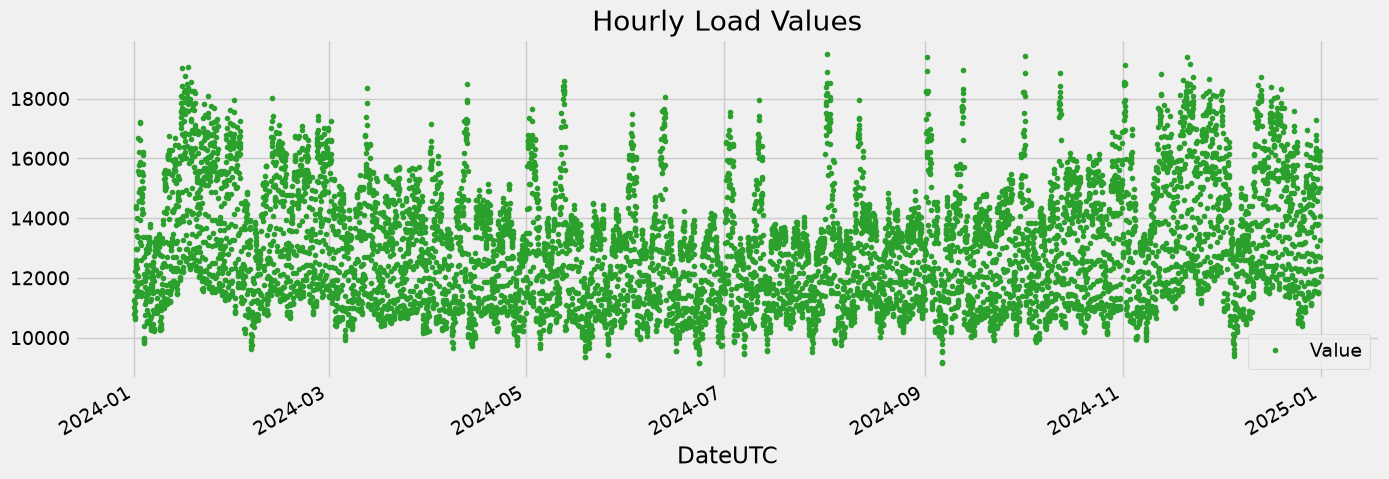

In [7]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[2],
        title='Hourly Load Values')
plt.show()

# Train / Test Split

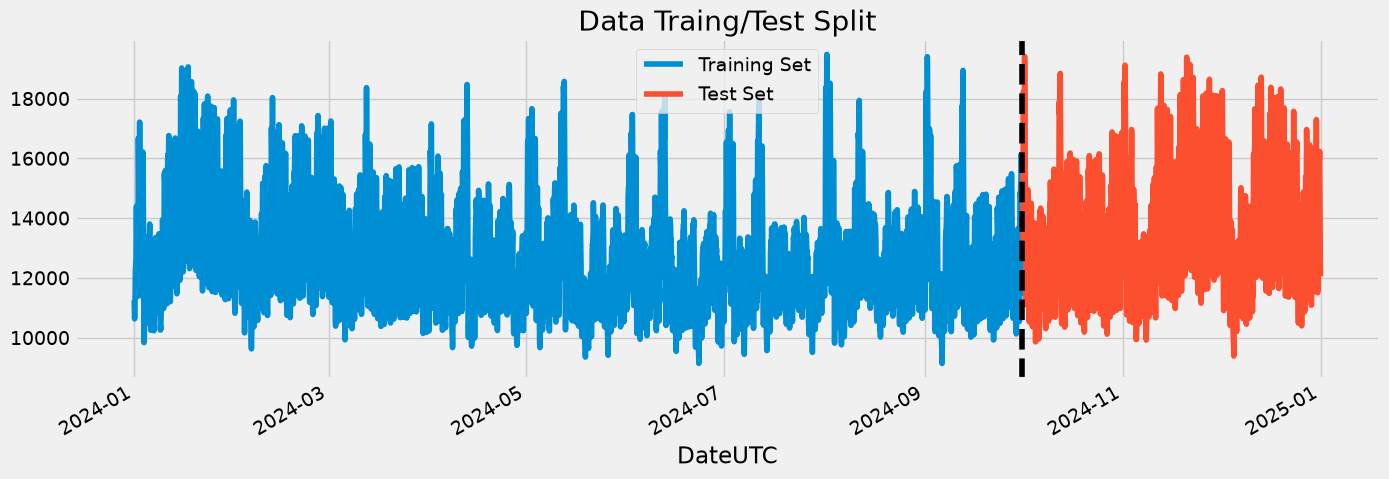

In [10]:
train = df.loc[df.index < '10-01-2024']
test = df.loc[df.index >= '10-01-2024']

fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label='Training Set', title='Data Traing/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('10-01-2024', color='black', ls='--')

ax.legend(['Training Set', 'Test Set'])
plt.show()

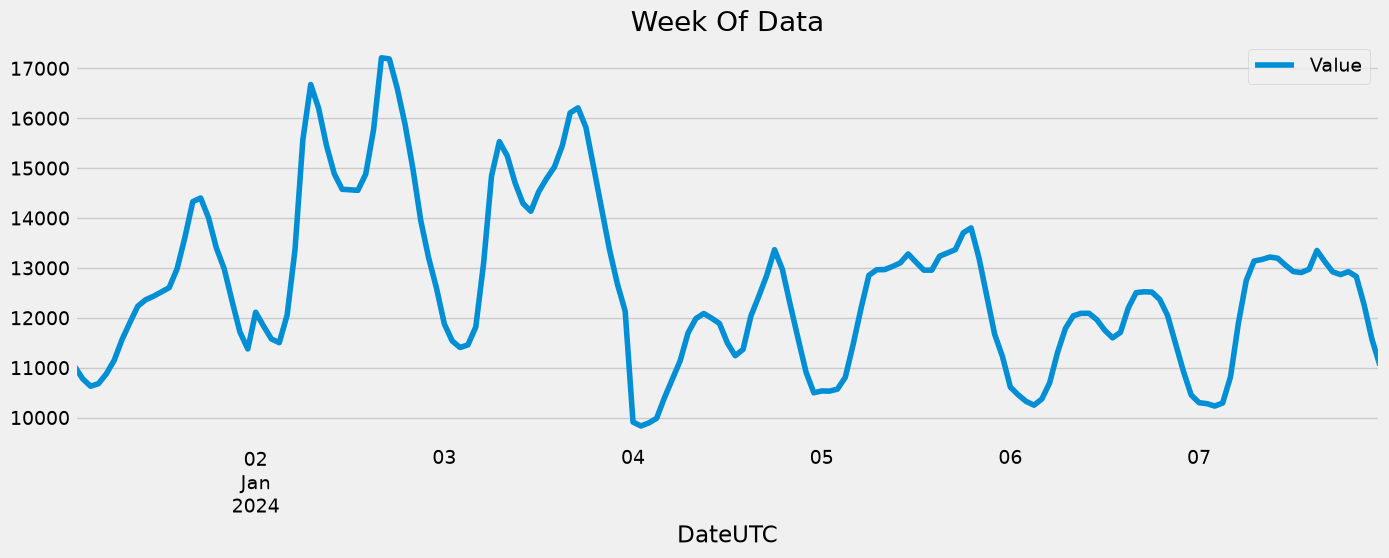

In [11]:
df.loc[(df.index > '01-01-2024') & (df.index < '01-08-2024')].plot(figsize=(15, 5), title='Week Of Data')
plt.show()

# Feature Creation

In [14]:
def create_features(df):

    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

# Visualize our Feature / Target Relationship

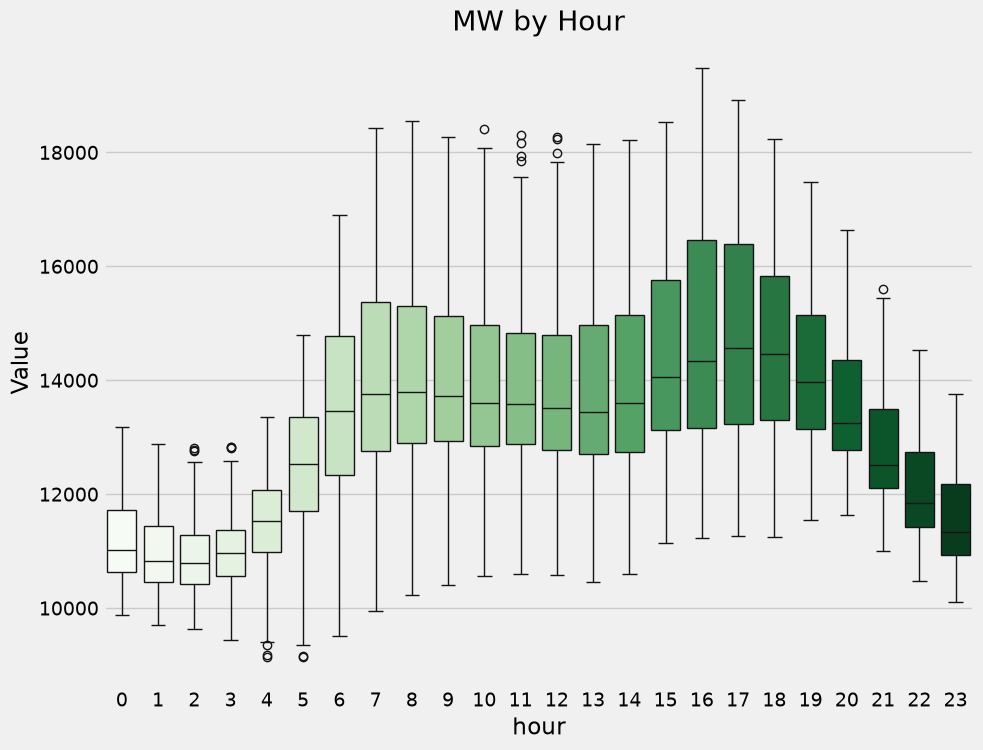

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='Value', hue='hour', palette='Greens', legend=False)

ax.set_title('MW by Hour')
plt.show()

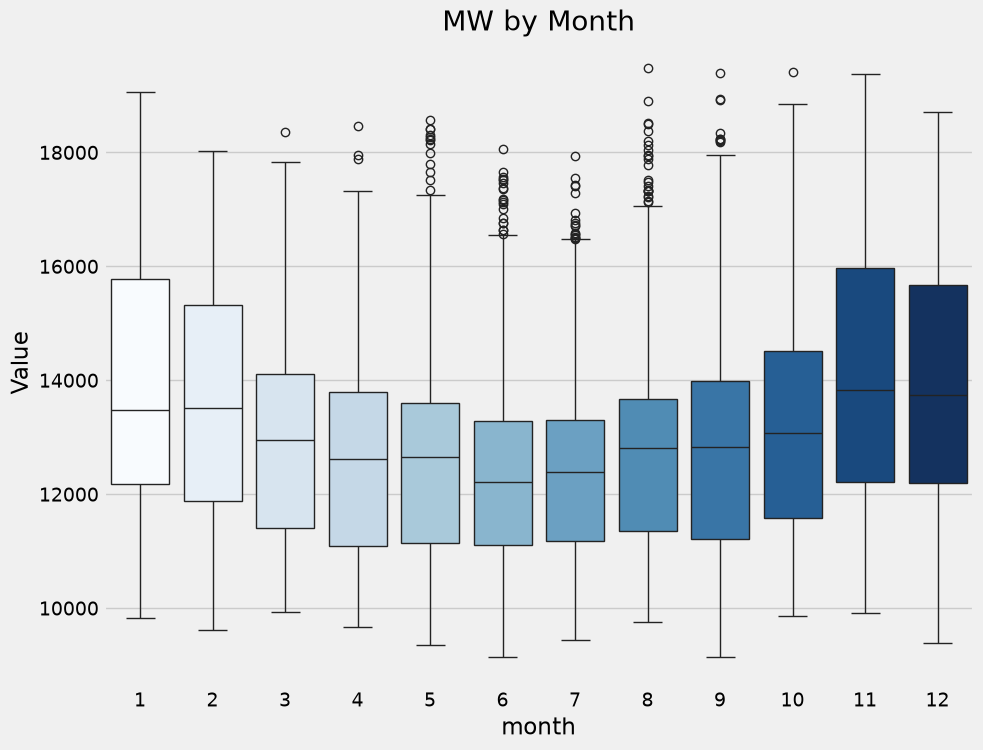

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='Value', hue='month', palette='Blues', legend=False)
ax.set_title('MW by Month')
plt.show()

# Create our Model

In [22]:
train = create_features(train)
test = create_features(test)
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'dayofyear',
       'dayofmonth']
TARGET= 'Value'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [23]:
reg = xgb.XGBRegressor(base_score = 0.5, booster = 'gbtree',
                       n_estimators = 1000,
                       early_stopping_rounds = 50,
                       objective = 'reg:squarederror',
                       max_depth = 3,
                       learning_rate = 0.01)
reg.fit(X_train, y_train,
       eval_set = [(X_train, y_train), (X_test, y_test)],
       verbose = 100)

[0]	validation_0-rmse:12884.74655	validation_1-rmse:13777.49165
[100]	validation_0-rmse:4862.59105	validation_1-rmse:5891.93134
[200]	validation_0-rmse:2052.94726	validation_1-rmse:3180.50897
[300]	validation_0-rmse:1171.15926	validation_1-rmse:2280.64319
[400]	validation_0-rmse:926.08020	validation_1-rmse:1978.15430
[500]	validation_0-rmse:845.05285	validation_1-rmse:1842.96314
[600]	validation_0-rmse:803.24509	validation_1-rmse:1744.96162
[700]	validation_0-rmse:774.69982	validation_1-rmse:1688.34325
[800]	validation_0-rmse:752.27175	validation_1-rmse:1646.33965
[900]	validation_0-rmse:735.29146	validation_1-rmse:1615.35013
[999]	validation_0-rmse:718.07485	validation_1-rmse:1594.24614


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Feature Importance

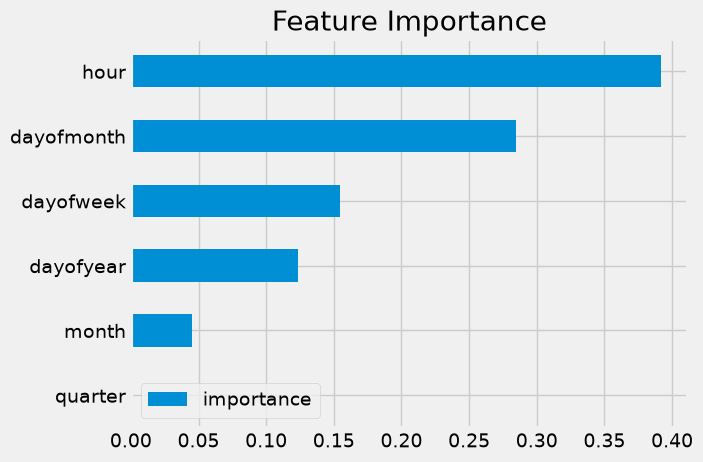

In [26]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

# Forecast on Test

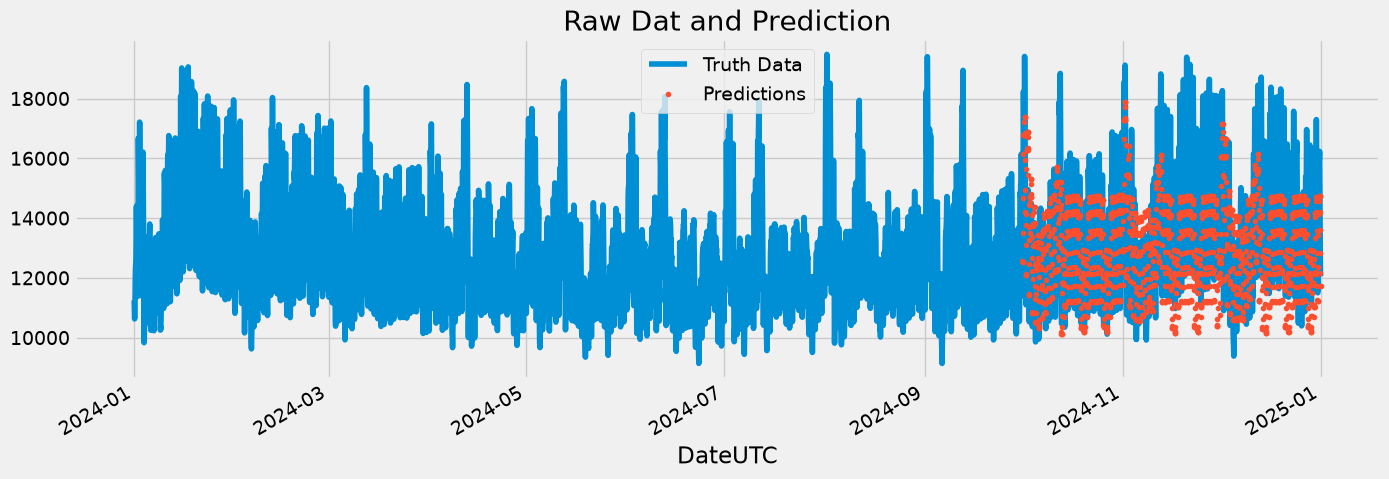

In [28]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['Value']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

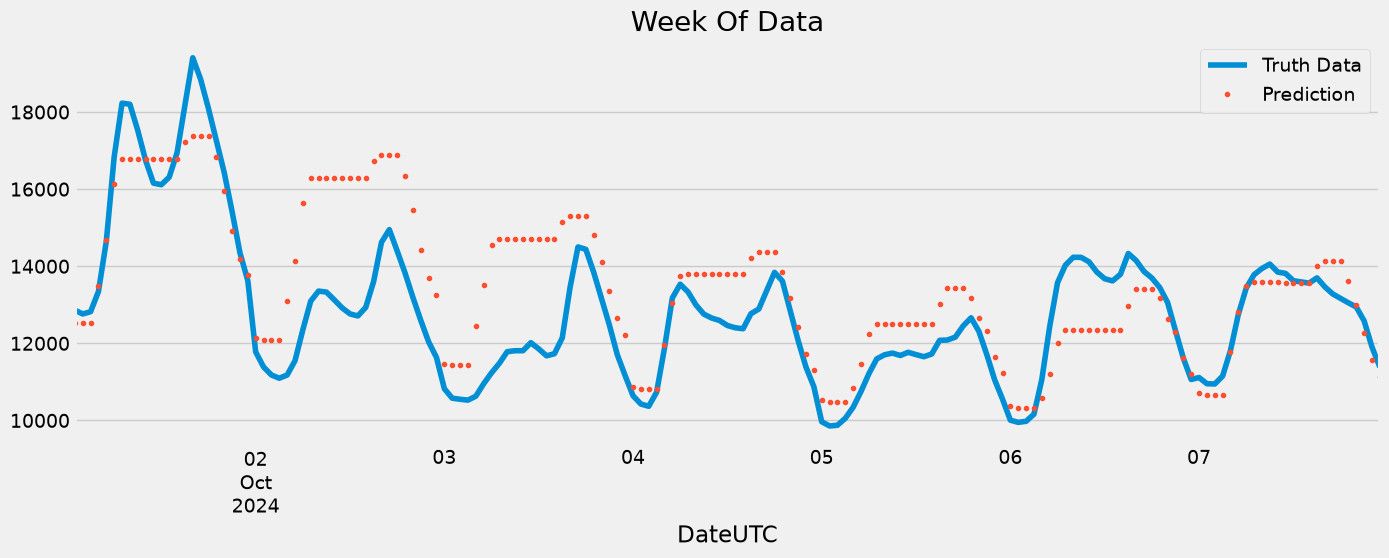

In [29]:
ax = df.loc[(df.index > '10-01-2024') & (df.index < '10-08-2024')]['Value'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '10-01-2024') & (df.index < '10-08-2024')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

# Score (RMSE)

In [33]:
score = np.sqrt(mean_squared_error(test['Value'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 1594.14


# Calculate Error

### Look at the worst and best predicted days

In [36]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(5)

date
2024-11-23    2790.234295
2024-12-14    2733.290155
2024-11-20    2603.502277
2024-12-13    2547.517352
2024-11-22    2496.552144
Name: error, dtype: float64

In [37]:
test.groupby(['date'])['error'].mean().sort_values(ascending=True).head(5)

date
2024-10-07    317.421165
2024-10-26    362.230028
2024-11-04    371.455815
2024-10-27    378.322427
2024-10-10    394.567992
Name: error, dtype: float64